In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = "../data/wbt_sst_city_runs/city_wbt_roni_dmi_lagged_JJAS.csv"

df = pd.read_csv(path)
df["ym"] = pd.to_datetime(df["ym"])

print(df.head())
print(df.columns)

   city         ym   wbt_mean    wbt_p95    wbt_p99  n_days  year  month  \
0  aden 1950-06-01  27.917027  28.973102  29.091581      30  1950      6   
1  aden 1950-07-01  26.631142  28.007933  28.320653      31  1950      7   
2  aden 1950-08-01  25.992714  26.585449  26.728090      31  1950      8   
3  aden 1950-09-01  26.438005  27.844123  27.909043      30  1950      9   
4  aden 1951-06-01  28.423363  29.132025  29.313393      30  1951      6   

       RONI       DMI  ...  RONI_lag4  RONI_lag5  RONI_lag6  DMI_lag0  \
0 -0.068305 -0.507386  ...  -0.683043  -0.504667        NaN -0.507386   
1 -0.203778 -0.042979  ...  -0.294963  -0.683043  -0.504667 -0.042979   
2 -0.213478 -0.301718  ...  -0.552008  -0.294963  -0.683043 -0.301718   
3 -0.717259 -0.650809  ...  -0.097156  -0.552008  -0.294963 -0.650809   
4  0.545517  0.363260  ...   0.073338  -0.438061   0.035022  0.363260   

   DMI_lag1  DMI_lag2  DMI_lag3  DMI_lag4  DMI_lag5  DMI_lag6  
0 -0.094705 -0.601963 -0.457930  0.10325

In [55]:
lags = range(7)
cities = df["city"].unique()

results = []

for city in cities:
    sub = df[df["city"] == city]

    for lag in lags:
        r_roni = sub["wbt_p95"].corr(sub[f"RONI_lag{lag}"])
        r_dmi  = sub["wbt_p95"].corr(sub[f"DMI_lag{lag}"])

        results.append({
            "city": city,
            "lag": lag,
            "RONI_corr": r_roni,
            "DMI_corr": r_dmi
        })

corr_df = pd.DataFrame(results)

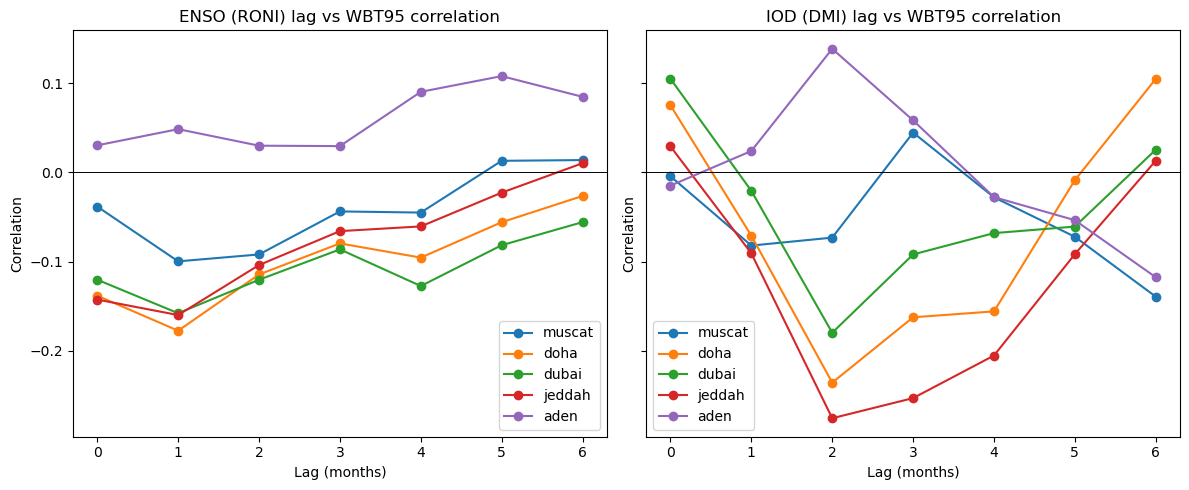

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

for city in cities:
    sub = corr_df[corr_df.city == city]

    axes[0].plot(sub.lag, sub.RONI_corr, marker="o", label=city)
    axes[1].plot(sub.lag, sub.DMI_corr, marker="o", label=city)

axes[0].set_title("ENSO (RONI) lag vs WBT95 correlation")
axes[1].set_title("IOD (DMI) lag vs WBT95 correlation")

for ax in axes:
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Correlation")
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/lagged/wbt_95_correlation_lags.png", dpi=300, bbox_inches="tight")
plt.show()

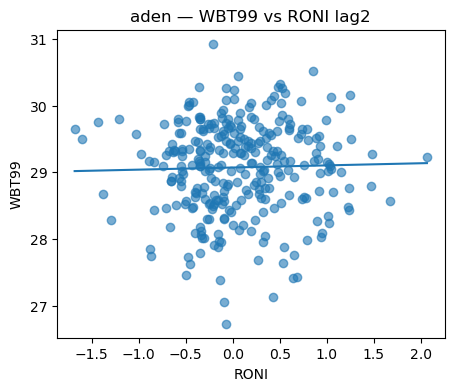

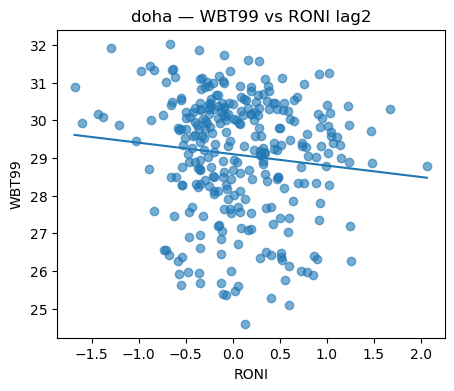

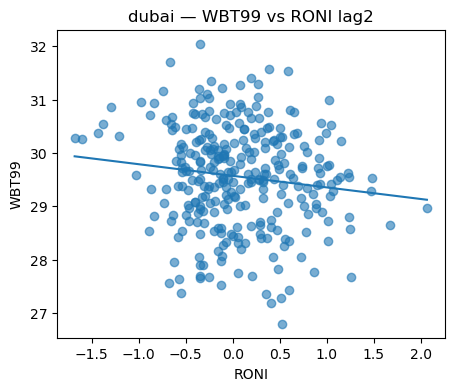

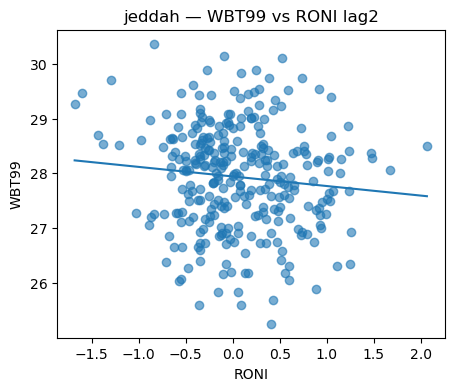

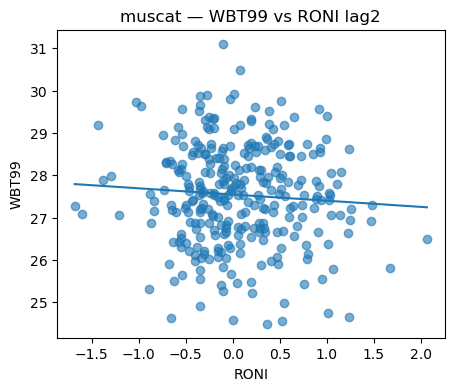

In [4]:
lag = 2

for city in df.city.unique():

    sub = df[df.city == city]

    plt.figure(figsize=(5,4))

    plt.scatter(sub[f"RONI_lag{lag}"], sub["wbt_p99"], alpha=0.6)

    m,b = np.polyfit(sub[f"RONI_lag{lag}"], sub["wbt_p99"],1)
    x = np.linspace(sub[f"RONI_lag{lag}"].min(), sub[f"RONI_lag{lag}"].max(),100)

    plt.plot(x, m*x+b)

    plt.title(f"{city} — WBT99 vs RONI lag{lag}")
    plt.xlabel("RONI")
    plt.ylabel("WBT99")

    plt.show()

In [5]:
df["ENSO_phase"] = "Neutral"

df.loc[df.RONI_lag2 >= 1, "ENSO_phase"] = "El Niño"
df.loc[df.RONI_lag2 <= -1, "ENSO_phase"] = "La Niña"

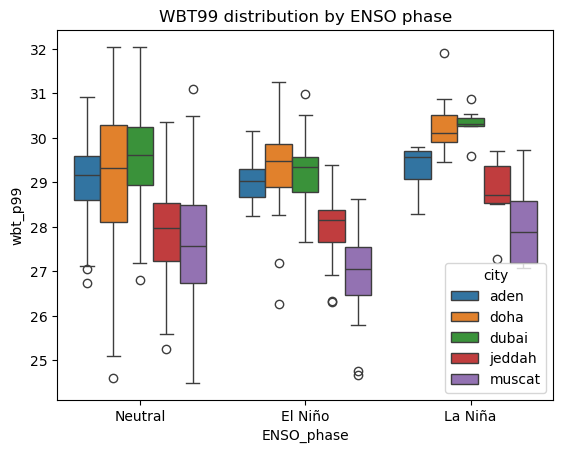

In [6]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="ENSO_phase",
    y="wbt_p99",
    hue="city"
)

plt.title("WBT99 distribution by ENSO phase")
plt.show()

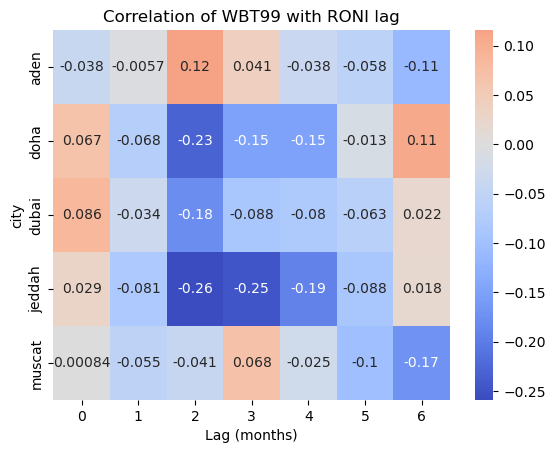

In [9]:
import seaborn as sns

pivot = corr_df.pivot(index="city", columns="lag", values="DMI_corr")

sns.heatmap(
    pivot,
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Correlation of WBT99 with RONI lag")
plt.xlabel("Lag (months)")
plt.sa
plt.show()

In [11]:
lags = range(7)
cities = df["city"].unique()

rows = []

for city in cities:
    sub = df[df.city == city]

    for lag in lags:

        r_roni = sub["wbt_p99"].corr(sub[f"RONI_lag{lag}"])
        r_dmi  = sub["wbt_p99"].corr(sub[f"DMI_lag{lag}"])

        rows.append({
            "city": city,
            "lag": lag,
            "RONI": r_roni,
            "DMI": r_dmi
        })

corr_df = pd.DataFrame(rows)

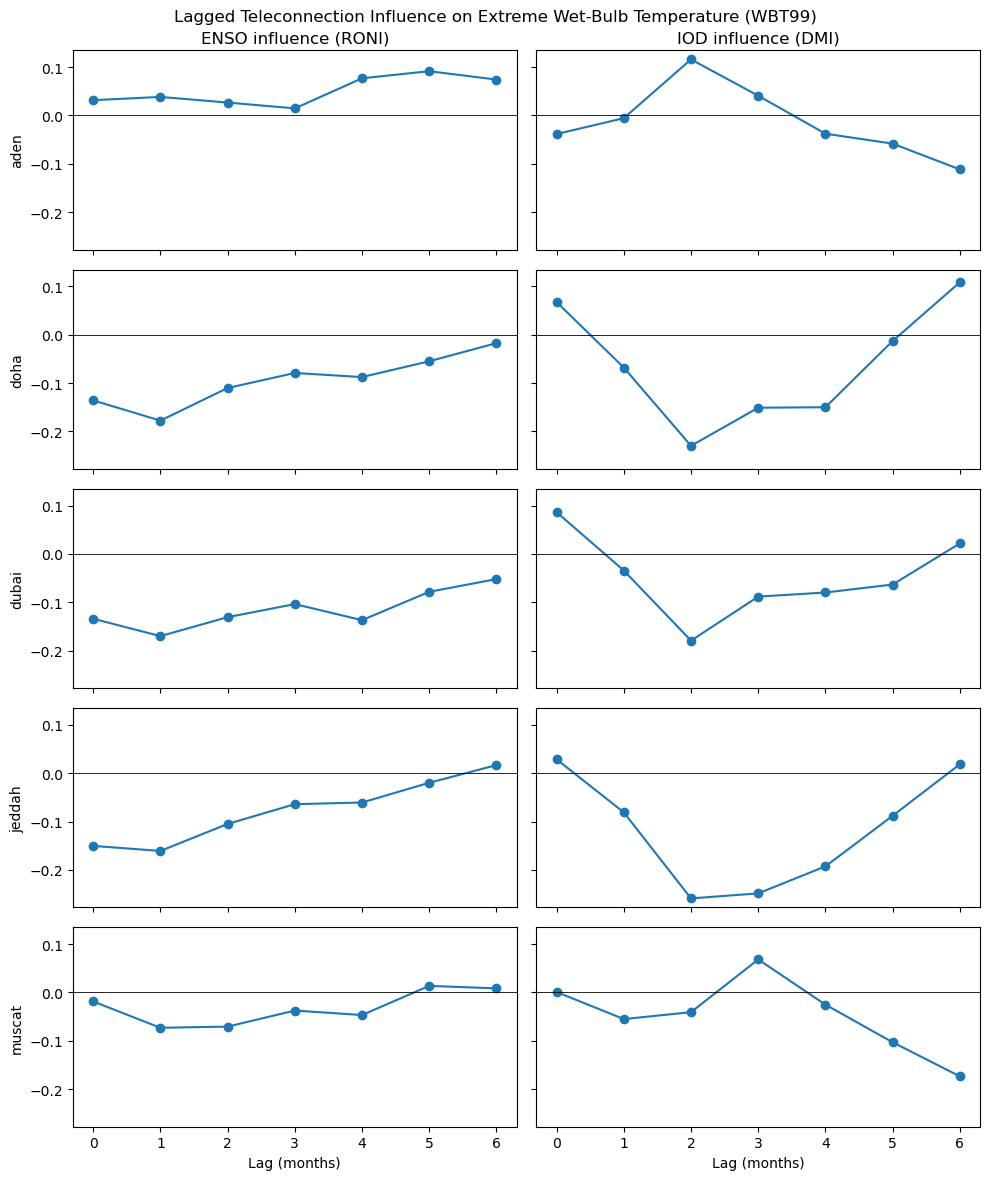

In [14]:
import os

cities = sorted(df["city"].unique())

fig, axes = plt.subplots(
    nrows=len(cities),
    ncols=2,
    figsize=(10, 12),
    sharex=True,
    sharey=True
)

for i, city in enumerate(cities):

    sub = corr_df[corr_df.city == city]

    # ENSO
    axes[i,0].plot(sub.lag, sub.RONI, marker="o")
    axes[i,0].axhline(0, color="k", lw=0.6)
    axes[i,0].set_ylabel(city)

    # IOD
    axes[i,1].plot(sub.lag, sub.DMI, marker="o")
    axes[i,1].axhline(0, color="k", lw=0.6)

axes[0,0].set_title("ENSO influence (RONI)")
axes[0,1].set_title("IOD influence (DMI)")

for ax in axes[-1]:
    ax.set_xlabel("Lag (months)")

plt.suptitle("Lagged Teleconnection Influence on Extreme Wet-Bulb Temperature (WBT99)")

plt.tight_layout()
os.makedirs("../figures/lagged/", exist_ok=True)
out_path = os.path.join("../figures/lagged/lagged_dmi_roni.png")
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

In [ ]:
okay I want a way to convey the lagged effects to the WBT at the mean 95th and 99th without

Text(0.5, 1.0, 'Cross correlation ENSO vs WBT99')

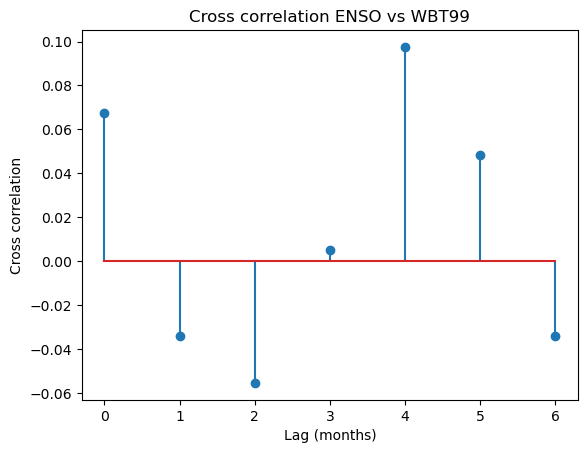

In [16]:
from statsmodels.tsa.stattools import ccf

city = "doha"
sub = df[df.city == city]

wbt = sub["wbt_p99"].values
dmi = sub["DMI"].values

ccf_vals = ccf(dmi, wbt)[:7]

plt.stem(range(7), ccf_vals)
plt.xlabel("Lag (months)")
plt.ylabel("Cross correlation")
plt.title("Cross correlation ENSO vs WBT99")

In [19]:
import statsmodels.api as sm

cols = ["wbt_p99"] + [f"RONI_lag{i}" for i in range(7)]

df_reg = sub[cols].dropna()

y = df_reg["wbt_p99"]
X = df_reg[[f"RONI_lag{i}" for i in range(7)]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                wbt_p99   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     2.082
Date:                Mon, 16 Mar 2026   Prob (F-statistic):             0.0454
Time:                        12:29:58   Log-Likelihood:                -551.92
No. Observations:                 299   AIC:                             1120.
Df Residuals:                     291   BIC:                             1149.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.1272      0.091    321.036      0.0

In [27]:
threshold = sub["wbt_p99"].quantile(0.95)

sub["extreme"] = sub["wbt_p99"] > threshold

lag = 1

sub["ENSO_phase"] = "Neutral"
sub.loc[sub[f"RONI_lag{lag}"] >= 1, "ENSO_phase"] = "El Niño"
sub.loc[sub[f"RONI_lag{lag}"] <= -1, "ENSO_phase"] = "La Niña"

sub["IOD_phase"] = "Neutral"
sub.loc[sub[f"DMI_lag{lag}"] >= 1, "IOD_phase"] = "pIOD"
sub.loc[sub[f"DMI_lag{lag}"] <= -1, "IOD_phase"] = "nIOD"

enso_prob = (
    sub.groupby("ENSO_phase")["extreme"]
    .mean()
)

iod_prob = (
    sub.groupby("IOD_phase")["extreme"]
    .mean()
)

print("ENSO extreme probability")
print(enso_prob)

print("\nIOD extreme probability")
print(iod_prob)

ENSO extreme probability
ENSO_phase
El Niño    0.076923
La Niña    0.333333
Neutral    0.037736
Name: extreme, dtype: float64

IOD extreme probability
IOD_phase
Neutral    0.052448
nIOD       0.000000
pIOD       0.000000
Name: extreme, dtype: float64


/tmp/ipykernel_37690/4174468067.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["extreme"] = sub["wbt_p99"] > threshold
/tmp/ipykernel_37690/4174468067.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["ENSO_phase"] = "Neutral"
/tmp/ipykernel_37690/4174468067.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [28]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

# --------------------------------------------------
# paths
# --------------------------------------------------
NETID = "k16v981"

BASE_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data"
WBT_DIR = os.path.join(BASE_DIR, "DailyPeakState")
WBT_GLOB = os.path.join(WBT_DIR, "DailyPeakState-*.nc")
IDX_CSV = os.path.join(BASE_DIR, "sst", "roni_dmi_monthly_1950_2025.csv")
OUT_DIR = os.path.join(BASE_DIR, "wbt_sst_city_runs")
os.makedirs(OUT_DIR, exist_ok=True)

CITIES = {
    "muscat": {"lat": 23.5880, "lon": 58.3829},
    "doha":   {"lat": 25.2854, "lon": 51.5310},
    "dubai":  {"lat": 25.2048, "lon": 55.2708},
    "jeddah": {"lat": 21.4858, "lon": 39.1925},
    "aden":   {"lat": 12.7855, "lon": 45.0187},
}

WBT_VAR = "wbt_daily_peak"
MAX_LAG = 6
JJAS_MONTHS = [6, 7, 8, 9]

# --------------------------------------------------
# helpers
# --------------------------------------------------
def to_0360(lon):
    return lon % 360

def infer_coord_name(ds, candidates):
    for c in candidates:
        if c in ds.coords or c in ds.dims:
            return c
    return None

def standardize_time_coord(ds):
    if "time" in ds.coords or "time" in ds.dims:
        return ds, "time"
    if "day" in ds.coords or "day" in ds.dims:
        ds = ds.rename({"day": "time"})
        return ds, "time"
    if "date" in ds.coords or "date" in ds.dims:
        ds = ds.rename({"date": "time"})
        return ds, "time"
    return ds, None

def open_one_file(path):
    try:
        return xr.open_dataset(path, engine="h5netcdf")
    except Exception:
        return xr.open_dataset(path)

def classify_phase(roni, dmi, thresh=1.0):
    if pd.isna(roni) or pd.isna(dmi):
        return np.nan

    if (roni >= thresh) and (dmi < thresh) and (dmi > -thresh):
        return "El Niño"
    elif (roni <= -thresh) and (dmi > -thresh) and (dmi < thresh):
        return "La Niña"
    elif (dmi >= thresh) and (roni < thresh) and (roni > -thresh):
        return "pIOD"
    elif (dmi <= -thresh) and (roni > -thresh) and (roni < thresh):
        return "nIOD"
    elif (roni >= thresh) and (dmi >= thresh):
        return "Joint +"
    elif (roni <= -thresh) and (dmi <= -thresh):
        return "Joint -"
    elif (roni >= thresh) and (dmi <= -thresh):
        return "Opposing El Niño"
    elif (roni <= -thresh) and (dmi >= thresh):
        return "Opposing La Niña"
    else:
        return "Neutral"

# --------------------------------------------------
# extract daily city WBT from original spatial files
# --------------------------------------------------
files = sorted(glob.glob(WBT_GLOB))
if not files:
    raise FileNotFoundError(f"No files matched: {WBT_GLOB}")

sample = open_one_file(files[0])
sample, time_name = standardize_time_coord(sample)

if WBT_VAR not in sample.data_vars:
    raise ValueError(f"{WBT_VAR} not found in sample file.")

lat_name = infer_coord_name(sample, ["lat", "latitude", "y"])
lon_name = infer_coord_name(sample, ["lon", "longitude", "x"])

if time_name is None:
    raise ValueError("Could not identify time coordinate.")
if lat_name is None or lon_name is None:
    raise ValueError("Could not identify lat/lon coordinates.")

use_0360 = float(sample[lon_name].max()) > 180

all_rows = []

for i, f in enumerate(files, start=1):
    if i == 1 or i % 25 == 0 or i == len(files):
        print(f"Processing {i}/{len(files)}: {os.path.basename(f)}")

    try:
        ds = open_one_file(f)
        ds, _ = standardize_time_coord(ds)

        if WBT_VAR not in ds.data_vars:
            print(f"  skipping {os.path.basename(f)}: missing {WBT_VAR}")
            continue

        da = ds[WBT_VAR]

        for city, meta in CITIES.items():
            lon = to_0360(meta["lon"]) if use_0360 else meta["lon"]

            point = da.sel(
                {lat_name: meta["lat"], lon_name: lon},
                method="nearest"
            )

            s = point.to_series()
            df_city = s.reset_index()
            value_col = df_city.columns[-1]
            df_city = df_city.rename(columns={value_col: "wbt_daily_peak"})

            if "time" not in df_city.columns:
                dt_cols = [c for c in df_city.columns if np.issubdtype(df_city[c].dtype, np.datetime64)]
                if len(dt_cols) == 0:
                    print(f"  skipping {city} in {os.path.basename(f)}: no datetime column")
                    continue
                df_city = df_city.rename(columns={dt_cols[0]: "time"})

            keep = ["time", "wbt_daily_peak"]
            if lat_name in df_city.columns:
                keep.append(lat_name)
            if lon_name in df_city.columns:
                keep.append(lon_name)

            df_city = df_city[keep].copy()
            df_city["city"] = city
            all_rows.append(df_city)

    except Exception as e:
        print(f"  failed on {os.path.basename(f)}: {e}")

if not all_rows:
    raise ValueError("No city time series were extracted.")

city_daily_wbt = pd.concat(all_rows, ignore_index=True)
city_daily_wbt["time"] = pd.to_datetime(city_daily_wbt["time"])
city_daily_wbt = city_daily_wbt.sort_values(["city", "time"]).reset_index(drop=True)

# keep JJAS only
city_daily_wbt["year"] = city_daily_wbt["time"].dt.year
city_daily_wbt["month"] = city_daily_wbt["time"].dt.month
city_daily_wbt["ym"] = city_daily_wbt["time"].dt.to_period("M").dt.to_timestamp()

city_daily_jjas = city_daily_wbt[city_daily_wbt["month"].isin(JJAS_MONTHS)].copy()

# --------------------------------------------------
# compute true city thresholds from daily JJAS WBT
# --------------------------------------------------
thresholds = (
    city_daily_jjas
    .groupby("city")["wbt_daily_peak"]
    .agg(
        p95=lambda x: np.nanpercentile(x, 95),
        p99=lambda x: np.nanpercentile(x, 99),
        n_days="count"
    )
    .reset_index()
)

city_daily_jjas = city_daily_jjas.merge(thresholds, on="city", how="left")
city_daily_jjas["exceed_p95"] = city_daily_jjas["wbt_daily_peak"] > city_daily_jjas["p95"]
city_daily_jjas["exceed_p99"] = city_daily_jjas["wbt_daily_peak"] > city_daily_jjas["p99"]

print("\nCity thresholds:")
print(thresholds)

# --------------------------------------------------
# read monthly RONI / DMI
# --------------------------------------------------
idx = pd.read_csv(IDX_CSV)

year_col = next((c for c in idx.columns if c.lower() == "year"), None)
month_col = next((c for c in idx.columns if c.lower() == "month"), None)
roni_col = next((c for c in idx.columns if "roni" in c.lower()), None)
dmi_col = next((c for c in idx.columns if "dmi" in c.lower()), None)

if year_col is not None and month_col is not None:
    idx["ym"] = pd.to_datetime(
        dict(
            year=idx[year_col].astype(int),
            month=idx[month_col].astype(int),
            day=1
        )
    )
else:
    time_col = next((c for c in idx.columns if c.lower() in ["time", "date", "datetime"]), None)
    if time_col is None:
        raise ValueError("Could not infer monthly date column in SST CSV.")
    idx["ym"] = pd.to_datetime(idx[time_col]).dt.to_period("M").dt.to_timestamp()

if roni_col is None or dmi_col is None:
    raise ValueError("Could not infer RONI/DMI columns.")

idx_monthly = (
    idx[["ym", roni_col, dmi_col]]
    .rename(columns={roni_col: "RONI", dmi_col: "DMI"})
    .sort_values("ym")
    .drop_duplicates("ym")
    .reset_index(drop=True)
)

# --------------------------------------------------
# build lagged monthly table with phase labels
# --------------------------------------------------
lag_tables = []

for lag in range(MAX_LAG + 1):
    tmp = idx_monthly.copy()
    tmp["RONI_lag"] = tmp["RONI"].shift(lag)
    tmp["DMI_lag"] = tmp["DMI"].shift(lag)
    tmp["lag"] = lag
    tmp["phase"] = [
        classify_phase(r, d, thresh=1.0)
        for r, d in zip(tmp["RONI_lag"], tmp["DMI_lag"])
    ]
    lag_tables.append(tmp[["ym", "lag", "RONI_lag", "DMI_lag", "phase"]])

idx_lag_phase = pd.concat(lag_tables, ignore_index=True)

# --------------------------------------------------
# merge daily data with lagged monthly phase
# --------------------------------------------------
daily_phase = city_daily_jjas.merge(idx_lag_phase, on="ym", how="left")

# --------------------------------------------------
# exceedance probabilities by city x lag x phase
# --------------------------------------------------
prob_phase = (
    daily_phase
    .dropna(subset=["phase"])
    .groupby(["city", "lag", "phase"], as_index=False)
    .agg(
        n_days=("wbt_daily_peak", "count"),
        n_exceed_p95=("exceed_p95", "sum"),
        n_exceed_p99=("exceed_p99", "sum"),
        prob_exceed_p95=("exceed_p95", "mean"),
        prob_exceed_p99=("exceed_p99", "mean"),
        mean_wbt=("wbt_daily_peak", "mean")
    )
)

# optional: risk ratio relative to Neutral within each city-lag
neutral = (
    prob_phase[prob_phase["phase"] == "Neutral"]
    [["city", "lag", "prob_exceed_p95", "prob_exceed_p99"]]
    .rename(columns={
        "prob_exceed_p95": "neutral_prob_p95",
        "prob_exceed_p99": "neutral_prob_p99"
    })
)

prob_phase = prob_phase.merge(neutral, on=["city", "lag"], how="left")
prob_phase["rr_p95_vs_neutral"] = prob_phase["prob_exceed_p95"] / prob_phase["neutral_prob_p95"]
prob_phase["rr_p99_vs_neutral"] = prob_phase["prob_exceed_p99"] / prob_phase["neutral_prob_p99"]

# --------------------------------------------------
# save outputs
# --------------------------------------------------
city_daily_jjas.to_csv(os.path.join(OUT_DIR, "city_daily_wbt_JJAS_with_thresholds.csv"), index=False)
thresholds.to_csv(os.path.join(OUT_DIR, "city_daily_wbt_JJAS_thresholds.csv"), index=False)
idx_monthly.to_csv(os.path.join(OUT_DIR, "roni_dmi_monthly_clean.csv"), index=False)
idx_lag_phase.to_csv(os.path.join(OUT_DIR, "roni_dmi_lagged_phase_0_6.csv"), index=False)
daily_phase.to_csv(os.path.join(OUT_DIR, "city_daily_wbt_JJAS_with_lagged_phases.csv"), index=False)
prob_phase.to_csv(os.path.join(OUT_DIR, "city_wbt_exceedance_probability_by_phase_lag.csv"), index=False)

print("\nSaved:")
print("  city_daily_wbt_JJAS_with_thresholds.csv")
print("  city_daily_wbt_JJAS_thresholds.csv")
print("  roni_dmi_monthly_clean.csv")
print("  roni_dmi_lagged_phase_0_6.csv")
print("  city_daily_wbt_JJAS_with_lagged_phases.csv")
print("  city_wbt_exceedance_probability_by_phase_lag.csv")

ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


Processing 1/900: DailyPeakState-195001.nc
Processing 25/900: DailyPeakState-195201.nc
Processing 50/900: DailyPeakState-195402.nc
Processing 75/900: DailyPeakState-195603.nc
Processing 100/900: DailyPeakState-195804.nc
Processing 125/900: DailyPeakState-196005.nc
Processing 150/900: DailyPeakState-196206.nc
Processing 175/900: DailyPeakState-196407.nc
Processing 200/900: DailyPeakState-196608.nc
Processing 225/900: DailyPeakState-196809.nc
Processing 250/900: DailyPeakState-197010.nc
Processing 275/900: DailyPeakState-197211.nc
Processing 300/900: DailyPeakState-197412.nc
Processing 325/900: DailyPeakState-197701.nc
Processing 350/900: DailyPeakState-197902.nc
Processing 375/900: DailyPeakState-198103.nc
Processing 400/900: DailyPeakState-198304.nc
Processing 425/900: DailyPeakState-198505.nc
Processing 450/900: DailyPeakState-198706.nc
Processing 475/900: DailyPeakState-198907.nc
Processing 500/900: DailyPeakState-199108.nc
Processing 525/900: DailyPeakState-199309.nc
Processing 550/

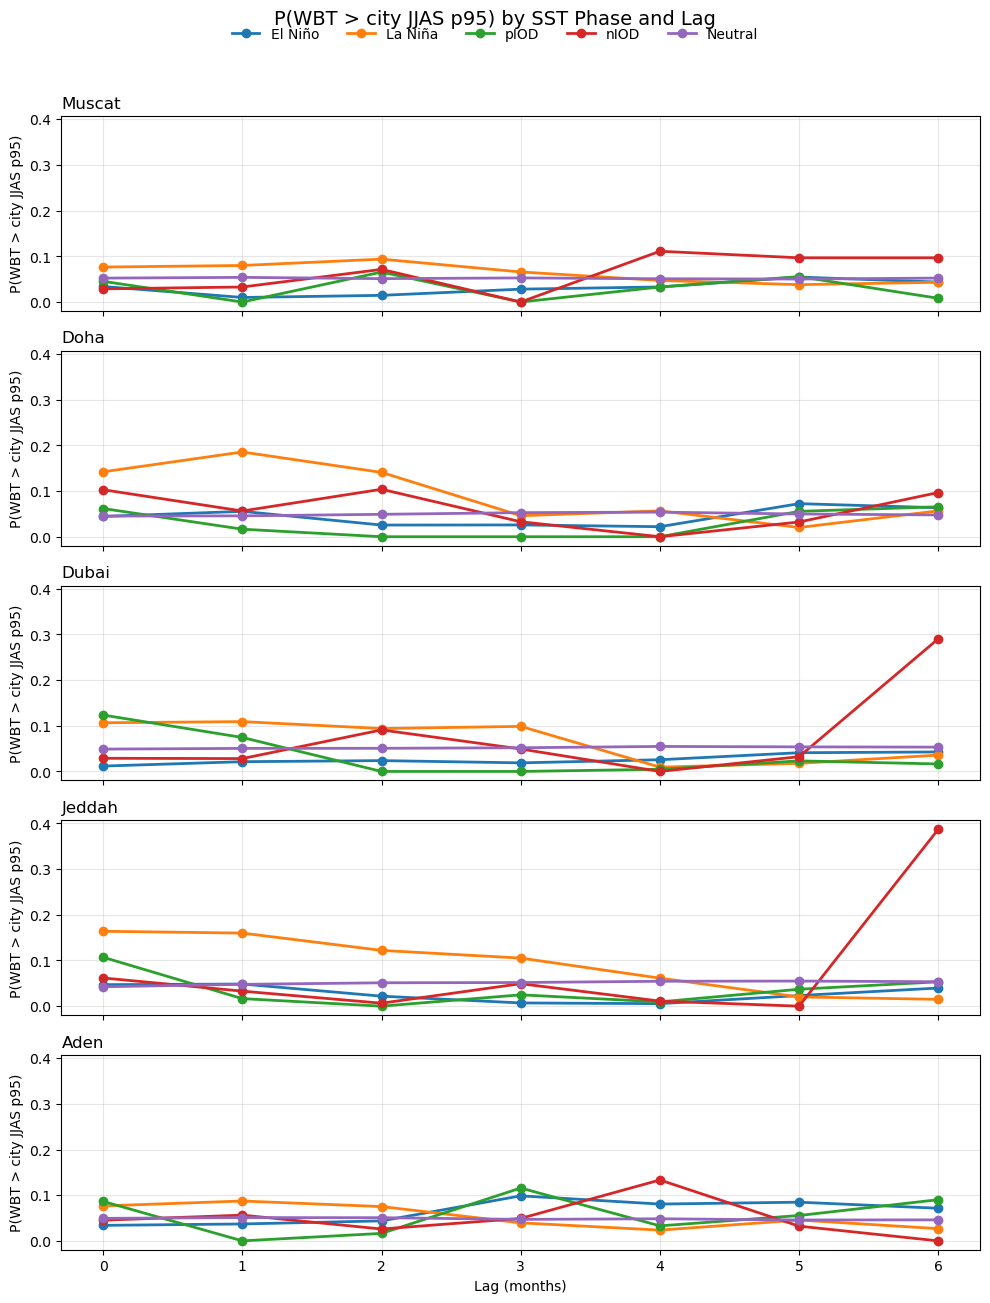

Saved: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/figures/lagged/city_phase_lag_exceedance_p95_lines.png


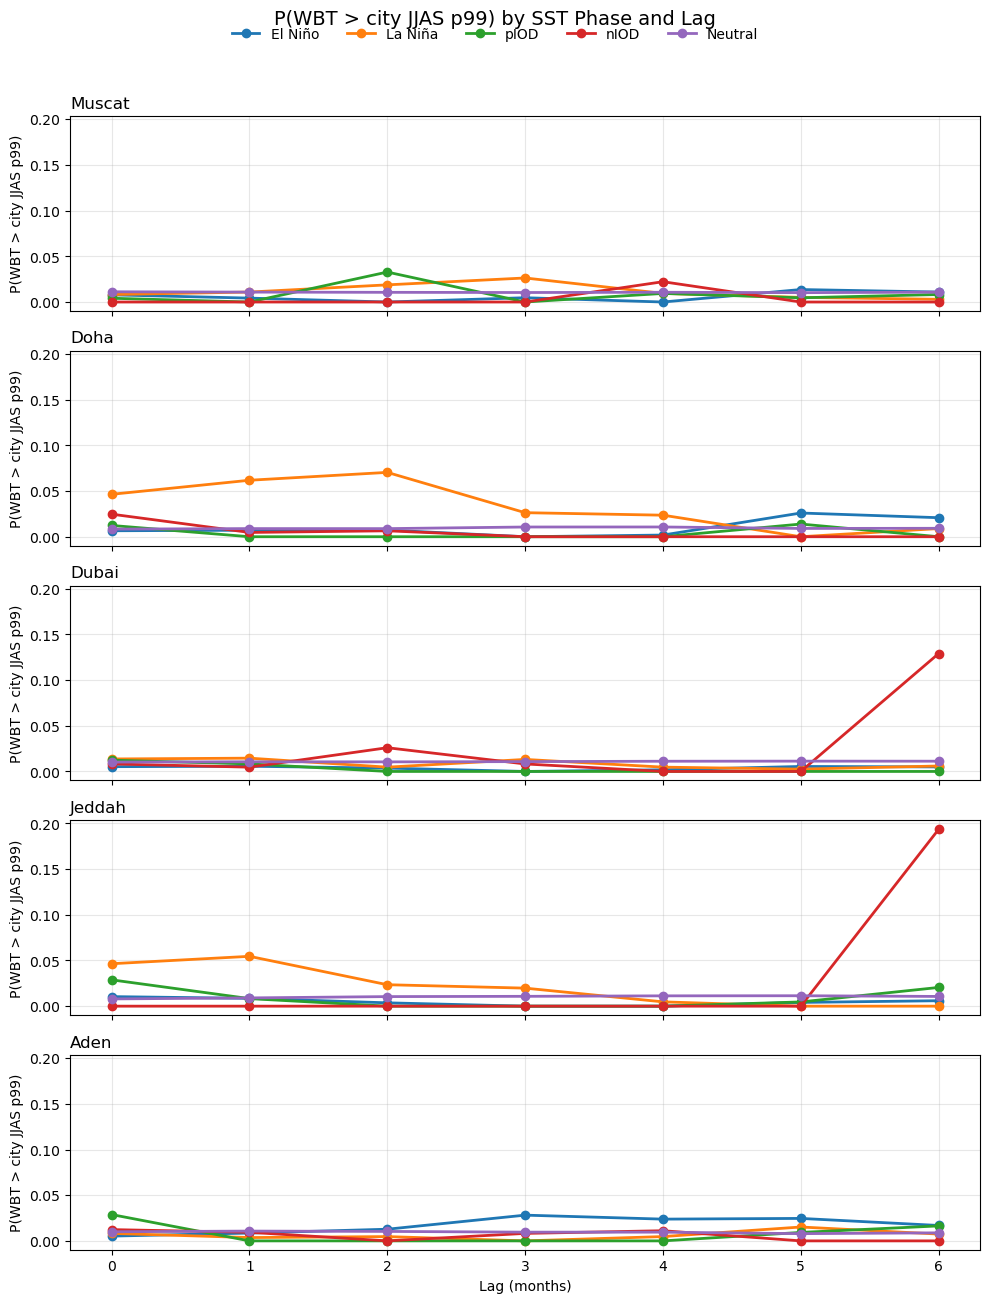

Saved: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/figures/lagged/city_phase_lag_exceedance_p99_lines.png


In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# paths
# --------------------------------------------------
NETID = "k16v981"
BASE_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes"
OUT_DIR = os.path.join(BASE_DIR, "data/wbt_sst_city_runs")
SAVE_DIR = os.path.join(BASE_DIR, "figures/lagged")

prob = pd.read_csv(os.path.join(OUT_DIR, "city_wbt_exceedance_probability_by_phase_lag.csv"))

# --------------------------------------------------
# keep only standard 4 phases + neutral
# --------------------------------------------------
phase_order = ["El Niño", "La Niña", "pIOD", "nIOD", "Neutral"]
city_order = ["muscat", "doha", "dubai", "jeddah", "aden"]

prob = prob[prob["phase"].isin(phase_order)].copy()
prob["phase"] = pd.Categorical(prob["phase"], categories=phase_order, ordered=True)
prob["city"] = pd.Categorical(prob["city"], categories=city_order, ordered=True)
prob = prob.sort_values(["city", "phase", "lag"])

# --------------------------------------------------
# plotting function
# --------------------------------------------------
def plot_exceedance_lines(df, metric, ylabel, outname):
    fig, axes = plt.subplots(
        nrows=len(city_order),
        ncols=1,
        figsize=(10, 13),
        sharex=True,
        sharey=True
    )

    if len(city_order) == 1:
        axes = [axes]

    for ax, city in zip(axes, city_order):
        sub = df[df["city"] == city].copy()

        for phase in phase_order:
            s = sub[sub["phase"] == phase].sort_values("lag")
            if len(s) == 0:
                continue

            ax.plot(
                s["lag"],
                s[metric],
                marker="o",
                linewidth=2,
                label=phase
            )

        ax.set_title(city.title(), loc="left", fontsize=12)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(0, 7))

    axes[-1].set_xlabel("Lag (months)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 0.995)
    )

    fig.suptitle(f"{ylabel} by SST Phase and Lag", y=0.999, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    outpath = os.path.join(SAVE_DIR, outname)
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outpath}")

# --------------------------------------------------
# make the two figures
# --------------------------------------------------
plot_exceedance_lines(
    prob,
    metric="prob_exceed_p95",
    ylabel="P(WBT > city JJAS p95)",
    outname="city_phase_lag_exceedance_p95_lines.png"
)

plot_exceedance_lines(
    prob,
    metric="prob_exceed_p99",
    ylabel="P(WBT > city JJAS p99)",
    outname="city_phase_lag_exceedance_p99_lines.png"
)

/tmp/ipykernel_37690/3359357621.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("city")["wbt_daily_peak"]
/tmp/ipykernel_37690/3359357621.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  enso[enso["city"] == city]
/tmp/ipykernel_37690/3359357621.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  en

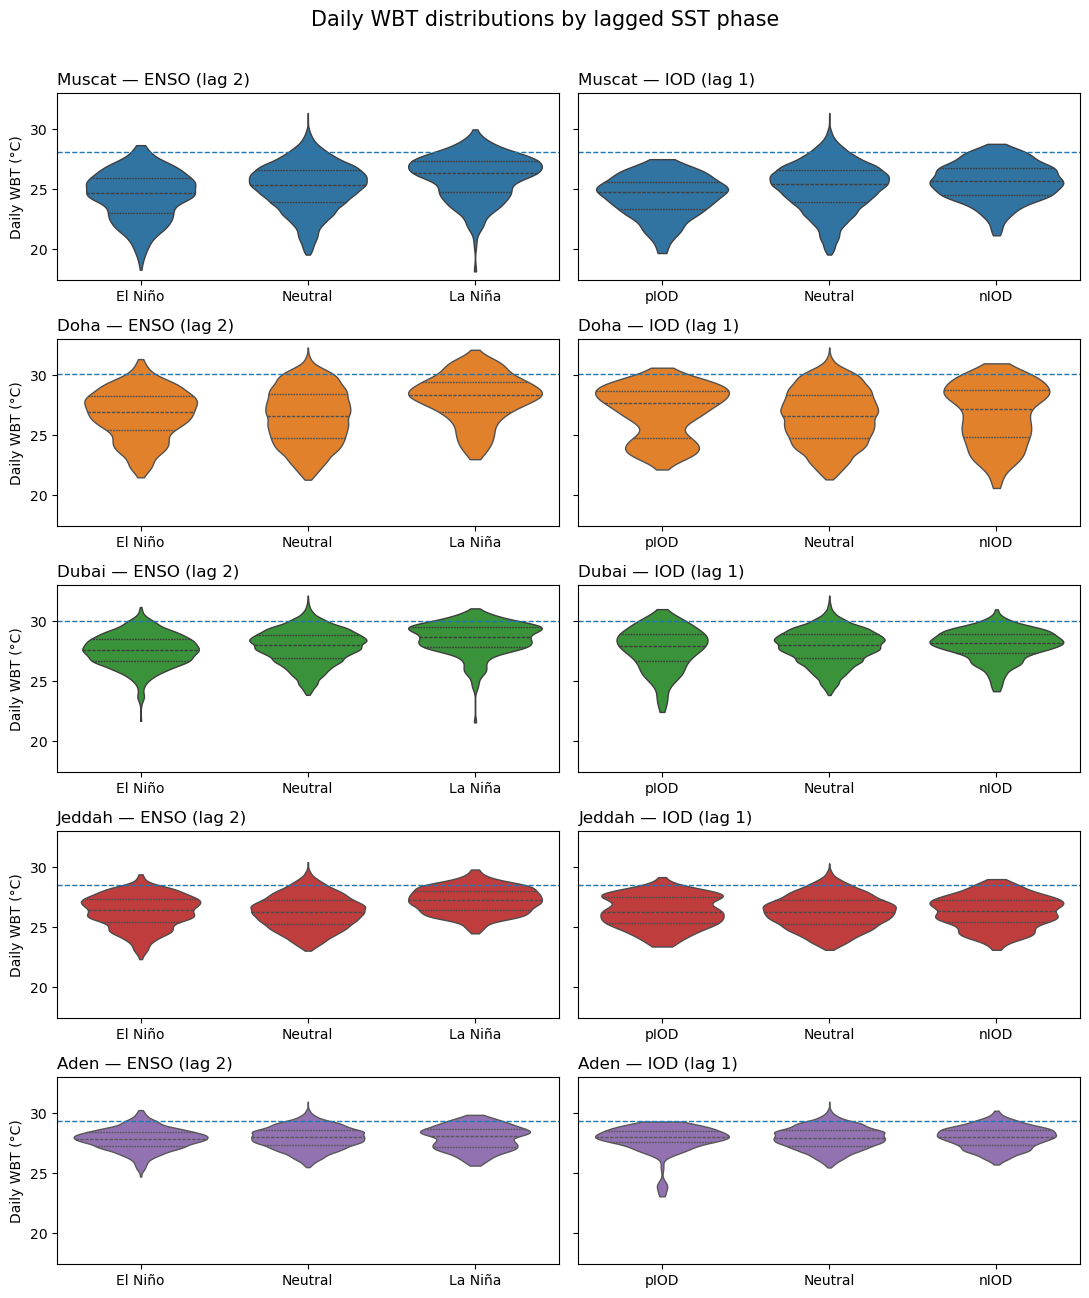

In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# paths
# --------------------------------------------------
NETID = "k16v981"
BASE_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes"
SAVE_DIR = os.path.join(BASE_DIR, "figures/lagged")
DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "wbt_sst_city_runs",
    "city_daily_wbt_JJAS_with_lagged_phases.csv"
)

df = pd.read_csv(DATA_PATH)

# --------------------------------------------------
# trim function
# --------------------------------------------------
def trim_neutral_only(group, col="wbt_daily_peak", q=0.01):
    if group.name == "Neutral":
        lower = group[col].quantile(q)   # bottom 1%
        return group[group[col] >= lower]
    return group

# --------------------------------------------------
# settings
# --------------------------------------------------
ENSO_LAG = 2
IOD_LAG = 1

cities = ["muscat", "doha", "dubai", "jeddah", "aden"]

city_colors = {
    "muscat": "tab:blue",
    "doha": "tab:orange",
    "dubai": "tab:green",
    "jeddah": "tab:red",
    "aden": "tab:purple",
}

# enforce city order
df["city"] = pd.Categorical(df["city"], categories=cities, ordered=True)
df = df.sort_values("city")

# --------------------------------------------------
# subset data
# --------------------------------------------------
enso = df[df["lag"] == ENSO_LAG].copy()
enso = enso[enso["phase"].isin(["El Niño", "La Niña", "Neutral"])].copy()

iod = df[df["lag"] == IOD_LAG].copy()
iod = iod[iod["phase"].isin(["pIOD", "nIOD", "Neutral"])].copy()

enso["phase"] = pd.Categorical(
    enso["phase"],
    categories=["El Niño", "Neutral", "La Niña"],
    ordered=True
)

iod["phase"] = pd.Categorical(
    iod["phase"],
    categories=["pIOD", "Neutral", "nIOD"],
    ordered=True
)

# --------------------------------------------------
# city-specific thresholds
# --------------------------------------------------
thresholds = (
    df.groupby("city")["wbt_daily_peak"]
    .quantile(0.95)
    .to_dict()
)

# --------------------------------------------------
# plot
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(cities),
    ncols=2,
    figsize=(11, 13),
    sharex=False,
    sharey=True
)

for i, city in enumerate(cities):
    color = city_colors[city]

    sub_enso = (
        enso[enso["city"] == city]
        .groupby("phase", group_keys=False)
        .apply(trim_neutral_only)
        .copy()
    )

    sub_iod = (
        iod[iod["city"] == city]
        .groupby("phase", group_keys=False)
        .apply(trim_neutral_only)
        .copy()
    )

    sns.violinplot(
        data=sub_enso,
        x="phase",
        y="wbt_daily_peak",
        ax=axes[i, 0],
        color=color,
        inner="quartile",
        cut=0,
        bw_adjust=0.8,
        linewidth=1
    )

    sns.violinplot(
        data=sub_iod,
        x="phase",
        y="wbt_daily_peak",
        ax=axes[i, 1],
        color=color,
        inner="quartile",
        cut=0,
        bw_adjust=0.8,
        linewidth=1
    )

    axes[i, 0].axhline(thresholds[city], linestyle="--", linewidth=1)
    axes[i, 1].axhline(thresholds[city], linestyle="--", linewidth=1)

    axes[i, 0].set_title(f"{city.title()} — ENSO (lag {ENSO_LAG})", loc="left")
    axes[i, 1].set_title(f"{city.title()} — IOD (lag {IOD_LAG})", loc="left")

    axes[i, 0].set_ylabel("Daily WBT (°C)")
    axes[i, 1].set_ylabel("")
    axes[i, 0].set_xlabel("")
    axes[i, 1].set_xlabel("")

plt.suptitle("Daily WBT distributions by lagged SST phase", fontsize=15, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
outpath = os.path.join(SAVE_DIR, "WBT_p95_violins.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()